In [1]:
import sys
sys.path.append('/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF')

import os

from loadData import data_pipe
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [1]))
print('using GPU %s' % ','.join(map(str, [1])))

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import SequentialLR, StepLR, LambdaLR
from thop import profile, clever_format

import cv2
import csv
import time
import json
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe, data_reader
from loadData.split_data import HyperX2, HyperX3
from loadData.dataAugmentation import DataAugmentation

from models import vision_transformer, CNNBase, vision_transformer_dino
from models import automaticWeightedLoss, modules
from models.MS2CANet import pymodel
# from models.Morphs import morphFormer2
from utils import trainer, tester, infoNCE, tools, focalLoss
from utils import mutual_info, distillation, CELoss, visulization

# from utils import orthogonalLoss
from sklearn.feature_selection import f_regression, mutual_info_regression

using GPU 1


/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [ ]:
args = opt.get_args()
# args.dataset_name = "IndianPines"
# args.dataset_name = "PaviaU"
args.dataset_name = "Houston_2013"
# args.dataset_name = "Houston_2018"

# args.backbone = "MiViT"
args.backbone = "resNet2"
# args.backbone = "resNet4"
# args.backbone = "morphFormer2"
# args.backbone = "vit_dino_s"
# args.backbone = "vit_dino_b"
# args.local_crops_number = 0

# args.split_type = "disjoint"
args.split_type = "ratio"

print("args.backbone", args.backbone)
# print("args.randomCrop", args.randomCrop)

args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/08-02-16-16-resNet2_Houston_2013"

args.backbone resNet2


In [3]:
args.epochs = 50
args.batch_size = 64
args.patch_size = 13
args.randomCrop = 11

# args.patch_size = 14
# args.randomCrop = 12

# args.patch_size = 6
# args.randomCrop = 4
args.pca = True
args.components = 15
# args.pca = False
# args.components = 0

args.lb_smooth = 0.1
args.learning_rate = 0.001
# args.learning_rate = 0.0005
args.weight_decay = 1e-3
args.lambda_contra = 0.1
args.lambda_orth = 0.1
args.lambda_kl = 0
args.lambda_super = 1
args.schedule = True
args.step_size = 30
args.gamma = 0.7

In [4]:
# data_pipe.set_deterministic(seed = 666)
args.print_data_info = False
args.data_info_start = 1
args.show_gt = False
args.remove_zero_labels = True
args.train_ratio = 1

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt, GT = data_pipe.get_data(args)
band1 = img1.shape[2]
band2 = img2.shape[2]
args.min = str(np.min(img1))
args.max = str(np.max(img1))
print("img1", img1.shape, "img2", img2.shape, band1, band2, args.min, args.max)
print("train_gt", train_gt.shape, \
		"test_gt", test_gt.shape, \
		"data_gt", data_gt.shape, \
		"GT", GT.shape)

img1 = img1[:, 1220:1683, :]
img2 = img2[:, 1220:1683, :]
# label = data_gt[:, 1220:1683]
print("after padding img.shape, gt.shape", img1.shape, img2.shape) 


img1 = cv2.resize(img1, (img1.shape[1]*2, img1.shape[0]*2), cv2.INTER_LINEAR)
img2 = cv2.resize(img2, (img2.shape[1]*2, img2.shape[0]*2), cv2.INTER_LINEAR)
img2 = img2[:, :, np.newaxis]
print("resized img.shape, gt.shape", img1.shape, img2.shape) 

pca is used
img1 (363, 1919, 15) img2 (363, 1919, 1) 15 1 -61.105827 69.57207
train_gt (363, 1919) test_gt (363, 1919) data_gt (363, 1919) GT (349, 1905)
after padding img.shape, gt.shape (363, 463, 15) (363, 463, 1)
resized img.shape, gt.shape (726, 926, 15) (726, 926, 1)


In [5]:
# 整个传入到 GPU 中
modality_1_t = torch.tensor(img1).to(args.device)
modality_2_t  = torch.tensor(img2).to(args.device)
# label_t  = torch.tensor(label).to(args.device)

modality_1_g = modality_1_t.permute(2, 0, 1).unsqueeze(0)
modality_2_g = modality_2_t.permute(2, 0, 1).unsqueeze(0)
# label_g = label_t.unsqueeze(0)
print("Size", modality_1_g.shape, modality_2_g.shape)

Size torch.Size([1, 15, 726, 926]) torch.Size([1, 1, 726, 926])


In [6]:
if args.backbone == "resNet2":
    encoder = CNNBase.Model_base(channell=band1, channel2=band2).to(args.device)
    args.feature_dim = 512
    # args.feature_dim = 2048

elif args.backbone == "vit_dino_s":
    selected_layers = [0, 2, 5, 7]  # 从 dinov2 中选择的层
    encoder = vision_transformer_dino.Vit_base(band1, band2, args.randomCrop, selected_layers=selected_layers).to(args.device)
    args.feature_dim = 384

elif args.backbone == "vit_dino_b":
    selected_layers = [0, 2, 5, 7]  # 从 dinov2 中选择的层
    encoder = vision_transformer_dino.vit_selected_base(band1, band2, args.randomCrop, selected_layers=selected_layers).to(args.device)
    args.feature_dim = 768 

In [7]:
from pathlib import Path
args.resume = Path(os.path.join(args.result_dir, "test_loss.pth"))

if args.resume.is_file():
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/08-02-16-06-resNet2_Houston_2013/test_loss.pth epoch 8


v1, v2 torch.Size([1, 512, 91, 116]) torch.Size([1, 512, 91, 116])
v_output_1 torch.Size([1, 91, 116])
v1_s (182, 232)


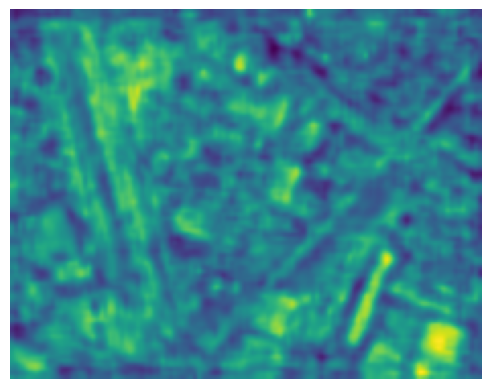

In [ ]:
v1, v2, v3 = encoder.get_visulization(modality_1_g, modality_2_g)
print("v1, v2", v1.shape, v2.shape)

v_output_1 = torch.mean(v1, dim=1)
print("v_output_1", v_output_1.shape)

v1_s = v_output_1.permute(0, 1, 2).squeeze().cpu().detach().numpy()
v1_s = cv2.resize(v1_s, (v1.shape[3]*4, v1.shape[2]*4), cv2.INTER_LINEAR)
print("v1_s", v1_s.shape)

# plt.imshow(v1_s, cmap='gray')
plt.imshow(v1_s, cmap='viridis')
# plt.imshow(v1_s)
plt.axis('off')
plt.savefig(os.path.join(args.result_dir, 'v1.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

v1, v2 torch.Size([1, 512, 91, 116]) torch.Size([1, 512, 91, 116])
v_output_1 torch.Size([1, 91, 116])
v2_s (182, 232)


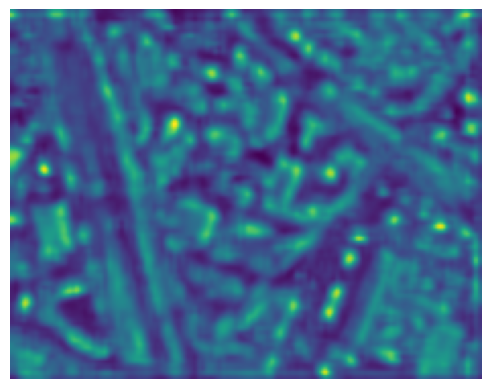

In [ ]:
v1, v2, v3 = encoder.get_visulization(modality_1_g, modality_2_g)
print("v1, v2", v1.shape, v2.shape)

v_output_2 = torch.mean(v2, dim=1)
print("v_output_1", v_output_2.shape)

v2_s = v_output_2.permute(0, 1, 2).squeeze().cpu().detach().numpy()
v2_s = cv2.resize(v2_s, (v2.shape[3]*4, v2.shape[2]*4), cv2.INTER_LINEAR)
print("v2_s", v2_s.shape)

# plt.imshow(v2_s, cmap='gray')
plt.imshow(v2_s, cmap='viridis')
# plt.imshow(v2_s)
plt.axis('off')
plt.savefig(os.path.join(args.result_dir, 'v1.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

v1, v2 torch.Size([1, 512, 91, 116]) torch.Size([1, 512, 91, 116])
v_output_3 torch.Size([1, 91, 116])
v3_s (182, 232)


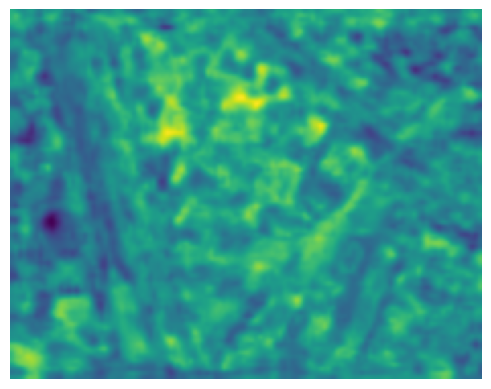

In [ ]:
v1, v2, v3 = encoder.get_visulization(modality_1_g, modality_2_g)
print("v1, v2", v1.shape, v2.shape)

v_output_3 = torch.mean(v3, dim=1)
print("v_output_3", v_output_2.shape)

v3_s = v_output_3.permute(0, 1, 2).squeeze().cpu().detach().numpy()
v3_s = cv2.resize(v3_s, (v3.shape[3]*4, v3.shape[2]*4), cv2.INTER_LINEAR)
print("v3_s", v3_s.shape)

# plt.imshow(v3_s, cmap='gray')
plt.imshow(v3_s, cmap='viridis')
# plt.imshow(v2_s)
plt.axis('off')
plt.savefig(os.path.join(args.result_dir, 'v1.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

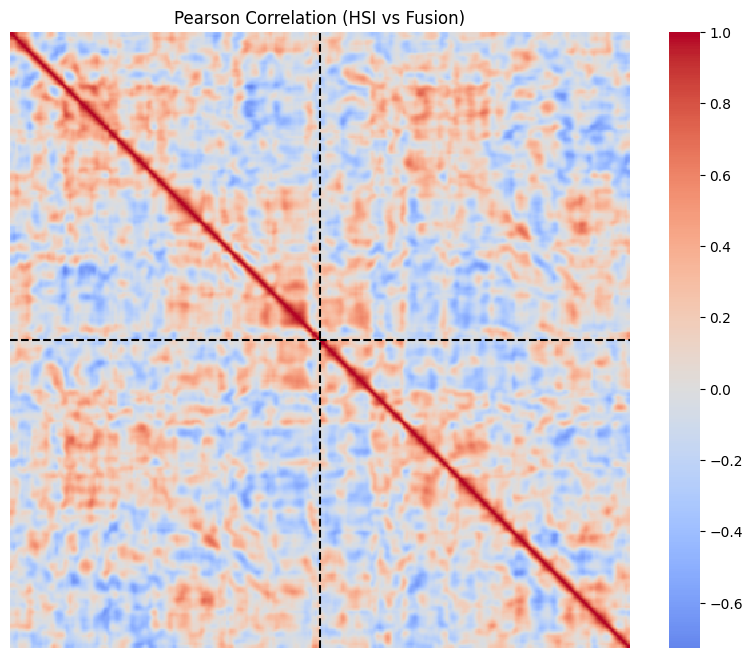

In [11]:
# 计算特征通道间的相关性
corr_matrix = np.corrcoef(v1_s.T, v3_s.T)
# corr_matrix, _ = spearmanr(v1_s, v3_s, axis=0)
# print("Correlation matrix:", corr_matrix)
# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.axvline(x=v1_s.shape[1], color='black', linestyle='--')
plt.axhline(y=v1_s.shape[1], color='black', linestyle='--')
plt.title("Pearson Correlation (HSI vs Fusion)")
plt.axis('off') 
# plt.show()
plt.savefig(os.path.join(args.result_dir, args.backbone + 'c13.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

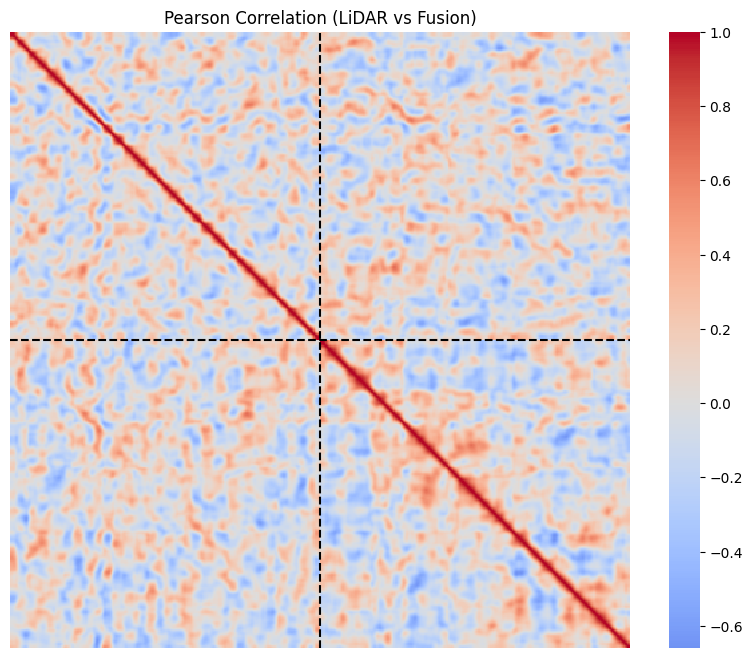

In [12]:
# 计算特征通道间的相关性
corr_matrix = np.corrcoef(v2_s.T, v3_s.T)
# corr_matrix, _ = spearmanr(v2_s, v3_s, axis=0)
# print("Correlation matrix:", corr_matrix)
# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.axvline(x=v1_s.shape[1], color='black', linestyle='--')
plt.axhline(y=v1_s.shape[1], color='black', linestyle='--')
plt.title("Pearson Correlation (LiDAR vs Fusion)")
plt.axis('off') 
# plt.show()
plt.savefig(os.path.join(args.result_dir, args.backbone + 'c23.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

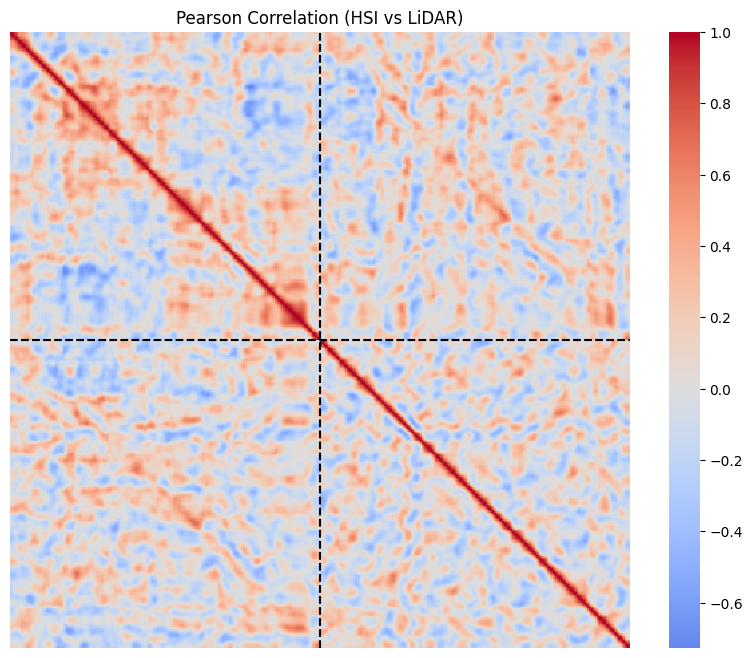

In [13]:
# 计算特征通道间的相关性
corr_matrix = np.corrcoef(v1_s.T, v2_s.T)
# corr_matrix, _ = spearmanr(v1_s, v2_s, axis=0)
# print("Correlation matrix:", corr_matrix)
# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.axvline(x=v1_s.shape[1], color='black', linestyle='--')
plt.axhline(y=v1_s.shape[1], color='black', linestyle='--')
plt.title("Pearson Correlation (HSI vs LiDAR)")
plt.axis('off') 
# plt.show()
plt.savefig(os.path.join(args.result_dir, args.backbone + 'c12.png'), bbox_inches='tight', pad_inches=0, dpi=200) 

# 类别激活图 CAM

In [ ]:
for name, param in model.named_parameters():
    # print(name)
    # param.requires_grad = False
    # print(param.requires_grad)      
    pass

In [ ]:
# # 这个有个缺点，需要有一个卷积层和最后一个全连接层 维度相同才能计算。暂时不要了
# # 选择一个类别 c，提取其对应权重向量 w_c
# w_c = model.fc3.weight[0]  # shape: [256]
# print("w_c", w_c.shape)

# # 将该类别权重与 feature map 做通道加权求和
# # 假设 v1 是你要使用的 feature map
# feature = v1.squeeze(0)  # shape: [64, H, W]
# print("feature", feature.shape)

# # 权重加权求和
# cam = torch.einsum("c, chw->hw", w_c, feature)  # shape: [H, W]

# cam = cam.cpu().detach().numpy()
# cam = (cam - cam.min()) / (cam.max() - cam.min())  # normalize to [0, 1]

# # 假设原图大小是 (H, W)
# H, W = modality_1.shape[:2]
# modality_1 = (modality_1 - modality_1.min()) / (modality_1.max() - modality_1.min()) 
# cam_resized = cv2.resize(cam, (W, H))

# # 然后叠加在原图上可视化
# plt.imshow(modality_1[:,:, [90,60,15]])
# plt.imshow(cam_resized, cmap='jet', alpha=0.5)
# # plt.imshow(cam, cmap='jet')
# plt.axis('off')  # 关闭坐标轴（等效于关闭刻度和边框）
# plt.tight_layout(pad=0)  # 去除额外空白边距
# plt.colorbar()
# # plt.savefig(os.path.join(args.result_dir, 'cam2.png'), dpi=200)

In [ ]:
# # 选择一个类别类别 c，提取其对应权重向量 w_c
# w_c = model.fc3.weight[0]  # shape: [256]
# print(w_c.shape)

# # 将该类别权重与 feature map 做通道加权求和
# # 假设 v1 是你要使用的 feature map
# feature = v2.squeeze(0)  # shape: [64, H, W]
# print(feature.shape)

# # 权重加权求和
# cam = torch.einsum("c,chw->hw", w_c, feature)  # shape: [H, W]

# cam = cam.cpu().detach().numpy()
# cam = (cam - cam.min()) / (cam.max() - cam.min())  # normalize to [0, 1]

# # 假设原图大小是 (H, W)
# H, W = modality_2.shape[:2]
# modality_2 = (modality_2 - modality_2.min()) / (modality_2.max() - modality_2.min()) 
# cam_resized = cv2.resize(cam, (W, H))

# # 然后叠加在原图上可视化
# plt.imshow(modality_2)
# plt.imshow(cam_resized, cmap='jet', alpha=0.5)
# # plt.imshow(cam, cmap='jet')
# plt.axis('off')  # 关闭坐标轴（等效于关闭刻度和边框）
# plt.tight_layout(pad=0)  # 去除额外空白边距
# plt.colorbar()
# # plt.savefig(os.path.join(args.result_dir, 'cam1.png'), dpi=200)

# 解耦:正交损失
- MI(A1, A2) 越小越互补	指的是原始低阶特征 → 去冗余
- 去相关约束（decorrelation / redundancy reduction）

# OrthogonalLoss

In [ ]:
# print(output_1.shape, output_2.shape)

# output_11 = output_1.cpu().reshape(1, -1)      # 把每个通道、空间点、样本都混在一起了,不能用于通道级分析（如正交性、互信息）
# output_22 = output_2.cpu().reshape(1, -1)
# print("output", output_11.shape, output_22.shape)
# print(type(output_11), output_11.shape)  # 应该是 torch.Tensor

# # 协方差 Frobenius 范数版本
# def orthogonal_loss(a1, a2):
#     a1 = a1 - a1.mean(dim=0, keepdim=True)
#     a2 = a2 - a2.mean(dim=0, keepdim=True)
#     cov = torch.matmul(a1.T, a2) / a1.size(0)  # [C1, C2]
#     return torch.norm(cov, p='fro') ** 2       # Frobenius norm of covariance

# o_loss1 = orthogonal_loss(output_11, output_22)
# print(o_loss1)


# # 版本 B：点积归一化版本
# def orthogonality_loss(a, b):
#     a = F.normalize(a, dim=1)  # 按样本归一化
#     b = F.normalize(b, dim=1)
#     dot_product = torch.sum(a * b, dim=1)  # [B]
#     return torch.mean(dot_product ** 2)

# o_loss2 = orthogonality_loss(output_11, output_22)
# print(o_loss2)

In [ ]:
class OrthogonalLoss(nn.Module):
    def __init__(self, version='frobenius', sample_size=None):
        super().__init__()
        assert version in ['frobenius', 'dot']
        self.version = version
        self.sample_size = sample_size

    def forward(self, a1, a2):
        if a1.ndim == 4:

            # 为什么可以将 B×H×W 统一展平为一个维度？	
            # 因为在 feature-level 对齐中，“每个位置”都是语义样本
            # 我们要比较的是模态 A 和 B 在相同位置提取出的表示是否相似、正交、互补
            a1 = a1.permute(0, 2, 3, 1).reshape(-1, a1.shape[1])    # [B×H×W, C]
            a2 = a2.permute(0, 2, 3, 1).reshape(-1, a2.shape[1])    # 每个“像素点”是一个样本, 每行是一个通道向量,用于统计分布、正交性、互信息分析最合理
            print("shape", a1.shape, a2.shape)
            
        if self.sample_size is not None and a1.size(0) > self.sample_size:
            idx = torch.randperm(a1.size(0))[:self.sample_size]
            a1, a2 = a1[idx], a2[idx]

        if self.version == 'frobenius':      # 协方差 Frobenius 范数版本
            a1 = a1 - a1.mean(dim=0, keepdim=True)
            a2 = a2 - a2.mean(dim=0, keepdim=True)
            cov = torch.matmul(a1.T, a2) / a1.size(0)
            return torch.norm(cov, p='fro') ** 2
        elif self.version == 'dot':          # 点积归一化版本
            a1 = F.normalize(a1, dim=1)
            a2 = F.normalize(a2, dim=1)
            dot = torch.sum(a1 * a2, dim=1)
            return torch.mean(dot ** 2)
        
        else:
            raise NotImplementedError("Not Implemented OrthogonalLoss")

In [ ]:
conv1 = nn.Conv2d(64, 32, 3, padding=1, bias=False).cuda()
output_1 = conv1(v1)

conv1 = nn.Conv2d(64, 32, 3, padding=1, bias=False).cuda()
output_2 = conv1(v2)
print(output_1.shape, output_2.shape)


orth_loss = OrthogonalLoss(version="frobenius", sample_size=2000)
o_loss = orth_loss(output_1, output_2)
print(o_loss)

# 通道间 Pearson 相关系数热图

In [ ]:
conv1 = nn.Conv2d(64, 3, 3, padding=1, bias=False).cuda()
output_1 = conv1(v1)
conv1 = nn.Conv2d(64, 3, 3, padding=1, bias=False).cuda()
output_2 = conv1(v2)
print(output_1.shape, output_2.shape)

output_11 = output_1.cpu().detach().numpy().reshape(-1, 3)
output_22 = output_2.cpu().detach().numpy().reshape(-1, 3)
print("output", output_11.shape, output_22.shape)

# 计算特征通道间的相关性
corr_matrix = np.corrcoef(output_11.T, output_22.T)

# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Cross-modal Feature Correlation (HSI vs LiDAR)")
plt.show()

- 描述：
	- 左上角（HSI 自相关）
	- 右下角（LiDAR 自相关）
	- 左下 / 右上角HSI 和 LiDAR 之间互信息很低，模态互补性强，没有冗余

# t-SNE / UMAP 显示像素特征分布

In [ ]:
from sklearn.manifold import TSNE

# 选定一小块像素（避免 10000+ 太慢）
N = 1000
idx = np.random.choice(output_11.shape[0], N, replace=False)

# 连接特征 + 添加标签
feat_all = np.concatenate([output_11[idx], output_22[idx]], axis=0)
labels = np.array([0]*N + [1]*N)  # 0: HSI, 1: LiDAR

# 降维
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embed = tsne.fit_transform(feat_all)

# 可视化
plt.figure(figsize=(6,6))
plt.scatter(embed[:N,0], embed[:N,1], c='blue', s=6, label="HSI")
plt.scatter(embed[N:,0], embed[N:,1], c='orange', s=6, label="LiDAR")
plt.axis('off')  # 关闭坐标轴（等效于关闭刻度和边框）
# plt.xticks(fontsize=12)  # x轴刻度字体大小为12
# plt.yticks(fontsize=12)  # y轴刻度字体大小为12
plt.legend(fontsize=12)
plt.title("t-SNE of HSI vs LiDAR Features", fontsize=12)
plt.savefig(os.path.join(args.result_dir, 't-SNE.png'), dpi=200)
plt.show()

#  Bonus：融合前后特征的互信息度量

In [ ]:
from sklearn.feature_selection import mutual_info_regression

# 对应位置向量之间的 MI（可能需要归一化）
mi_scores = []
for i in range(output_11.shape[1]):
    for j in range(output_22.shape[1]):
        mi = mutual_info_regression(output_11[:, [i]], output_22[:, j])
        mi_scores.append(mi[0])
avg_mi = np.mean(mi_scores)
print(f"Average mutual information between HSI and LiDAR features: {avg_mi:.4f}")

# MINE 损失值也是怪怪的，不太行

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class MINE(nn.Module):
#     """
#     Mutual Information Neural Estimation (MINE) for estimating I(X; Y)
#     计的是互信息的下界，估计值至少大于真实互信息：
#     在训练初期或输入无关时，这个下界估计值是可以为负数的
#     MINE 并不直接输出真实 MI；而是输出一个 trainable lower bound；
#     这个下界在随机初始化时误差很大，有可能落在 0 以下。
#     """
#     def __init__(self, input_dim, hidden_dim=128, momentum=0.9):
#         super(MINE, self).__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim * 2, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, 1)
#         )
#         self.register_buffer("ema_marg", torch.tensor(0.0))
#         self.momentum = momentum

#     def forward(self, x, y):
#         """
#         x: tensor of shape (B, D) -- modality A feature
#         y: tensor of shape (B, D) -- modality B feature
#         """
#         # Positive sample pairs: (x, y)
#         joint = torch.cat([x, y], dim=1)  # shape: (B, 2D)

#         # Negative sample pairs: (x, y_shuffled)
#         y_shuffle = y[torch.randperm(y.size(0))]
#         marginal = torch.cat([x, y_shuffle], dim=1)  # shape: (B, 2D)

#         # Discriminator output
#         T_joint = self.net(joint)
#         T_marg = self.net(marginal)

#         # 限制输出范围，避免梯度爆炸
#         T_joint = torch.clamp(T_joint, min=-50.0, max=50.0)
#         T_marg = torch.clamp(T_marg, min=-50.0, max=50.0)
#         # EMA update
#         marg_mean = torch.exp(T_marg).mean()
#         self.ema_marg = self.momentum * self.ema_marg + (1 - self.momentum) * marg_mean.detach()

#         # MINE loss (Donsker–Varadhan representation)
#         # mi_est = torch.mean(T_joint) - torch.log(torch.mean(torch.exp(T_marg)) + 1e-6)
#         mi_est = T_joint.mean() - torch.log(self.ema_marg + 1e-8)
#         return -mi_est  # we minimize it => suppress MI

In [ ]:
# # X = torch.randn(128, 256).cuda()    # 无关互信息
# # Y = torch.randn(128, 256).cuda()
# # print(X.shape, Y.shape)

# X = torch.randn(128, 256).cuda()
# Y = X + 0.05 * torch.randn(128, 256).cuda()  # 强相关但有噪声

# # # MI penalty
# # mine_loss = MINE(input_dim=256, hidden_dim=128).cuda()
# # mine_loss = mine_loss(X, Y)
# # print(mine_loss)

# mine = MINE(input_dim=256).cuda()
# mine.train()
# optimizer = torch.optim.Adam(mine.parameters(), lr=1e-3)


# TTloss = []
# for i in range(1000):
#     loss = mine(X, Y)
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
#     if i % 50 == 0:
#         print(f"Iter {i}, MI estimate: {-loss.item():.4f}")

#         TTloss.append(-loss.item())

In [ ]:
# for i in range(20):
# 	# print(i, TTloss[i])
# 	plt.plot(TTloss)

# CLUB 的根本问题（放弃）

- CLUB 本身并不是为“作为深度模型直接优化项”设计的 它是一种用于互信息估计的工具，而不是严格意义上的 loss 函数。

- CLUB 没有抑制机制
- CLUB 网络内部是一个纯拟合的网络；
- 没有“最大不能大于某值”的约束；
- 训练目标是最小化上界 loss，即负的互信息上界；
- 但由于这个上界可无限上升，模型会用缩小方差的方式让 loss 趋于负无穷。

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F


# class CLUB(nn.Module):
#     """
#     CLUB module estimates an upper bound of the mutual information I(X; Y).
#     Reference: Cheng, Min, et al. "CLUB: A Contrastive Log-ratio Upper Bound of Mutual Information." ICML 2020.
#     CLUB 是一种互信息的上界估计方法，估计值至少不会低估真实互信息。具有如下特点：
#     非对比学习方式，无需负样本构造；
#     对训练稳定性更好；
#     适合作为 互信息抑制 loss 使用。
#     """
#     def __init__(self, x_dim, y_dim, hidden_size=128):
#         super(CLUB, self).__init__()
#         # Estimate conditional mean E[Y|X]
#         self.mu_net = nn.Sequential(
#             nn.Linear(x_dim, hidden_size),
#             nn.ReLU(),
#             nn.Linear(hidden_size, y_dim)
#         )
#         # Estimate conditional log-variance log Var[Y|X]
#         self.logvar_net = nn.Sequential(
#             nn.Linear(x_dim, hidden_size),
#             nn.ReLU(),
#             nn.Linear(hidden_size, y_dim)
#         )

#     def forward(self, x, y):
#         """
#         Estimate mutual information upper bound I(X; Y)
#         x: (B, D)  -- modality A
#         y: (B, D)  -- modality B
#         """
#         mu = self.mu_net(x)        # predicted mean of y given x
#         logvar = self.logvar_net(x)  # predicted log-variance of y given x


#         # 数值稳定性保护：限制 logvar 的范围
#         logvar = torch.clamp(logvar, min=-6.0, max=6.0)
#         var = logvar.exp()
#         print("var", var.max().item(), var.min().item())
#         var = torch.clamp(var, min=1e-3, max=100.0)   # option


#         # Compute log-likelihood under predicted conditional Gaussian
#         positive = - (mu - y) ** 2 / (2.0 * var)
#         # positive = - (mu - y) ** 2 / 2. / logvar.exp()
#         positive = positive.sum(dim=1)  # shape: (B,)

#         # Shuffle y for negative sampling
#         random_index = torch.randperm(y.size(0))
#         y_shuffle = y[random_index]

#         negative = - (mu - y_shuffle) ** 2 / (2.0 * var)
#         negative = negative.sum(dim=1)  # shape: (B,)

#         mi_upper_bound = (positive - negative).mean()
#         # return -mi_upper_bound  # minimization to suppress MI
#         return -torch.log1p(torch.abs(mi_upper_bound))  # 限幅，防爆炸

In [ ]:
# X = torch.randn(128, 256).cuda()
# Y = torch.randn(128, 256).cuda()
# print(X.shape, Y.shape)

# # X = torch.randn(128, 256).cuda()
# # Y = X + 0.05 * torch.randn(128, 256).cuda()  # 强相关但有噪声


# # # MI penalty
# # club_loss = CLUB(x_dim=256, y_dim=256, hidden_size=128).cuda()
# # club_loss = club_loss(X, Y)
# # print(club_loss)


# club = CLUB(x_dim=256, y_dim=256, hidden_size=128).cuda()
# club.train()
# optimizer = torch.optim.Adam(club.parameters(), lr=1e-3)

# for i in range(1000):
#     loss = club(X, Y)
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
#     if i % 100 == 0:
#         print(f"Iter {i}, MI estimate: {-loss.item():.4f}")